In [49]:
import pandas as pd

# 1. Chargement de la base de données
df = pd.read_csv('allocinedoro.csv')

# 2. Liste des colonnes à supprimer
cols_to_drop = [
    'original_title',
    'press_rating',
    'audience_rating',
    'box_office_us',
    'synopsis',
    'sum_actors_fr_entries',
    'sum_directors_fr_entries',
    'actor_list',
    'director_list',
    'writer_list',
    'distributor_list',
    'genre_list',
    'nationality_list',
    'language_list',
    'sentence_ml'
]

# 3. Suppression des colonnes
df = df.drop(columns=cols_to_drop)

# 4. Vérification
print(f"Dimensions après nettoyage : {df.shape}")
df.head()


Dimensions après nettoyage : (9250, 11)


,title,release_date,duration,genres,box_office_fr,director,writer,actors,distributor,nationality,languages
0,notes laura fiori,2025-04-15,75.0,['drame'],14.0,[],[],"['ilaria benigna', 'raphael mathon', 'mathilde...",cinema saintandre des arts,['france'],['francais']
1,la colline aux gateaux,2025-04-14,59.0,"['aventure', 'animation', 'famille']",6453.0,['lise osvoll'],['anne elvedal'],"['fridtjov saheim', 'charlotte frogner', 'bjar...",NaN,['norvege'],['norvegien']
2,trois contes,2025-04-14,NaN,['animation'],109408.0,[],[],NaN,diaphana distribution,['france'],['francais']
3,la dame du jeu,2025-04-14,86.0,['comedie dramatique'],48522.0,[],[],"['jean yanne', 'francesco casale', 'noemie koc...",NaN,"['italie', 'france']",['']
4,napoleon 2eme partie,2025-04-14,NaN,['divers'],1371.0,[],[],NaN,NaN,[],['']


In [50]:
import pandas as pd

# --- 1. Afficher le nombre de NaN par colonne ---
print("Valeurs manquantes avant nettoyage :")
print(df.isna().sum().sort_values(ascending=False))

# --- 2. Identifier les types de colonnes ---
num_cols = df.select_dtypes(include=['number']).columns.tolist()
cat_cols = df.select_dtypes(exclude=['number']).columns.tolist()

print(f"\nColonnes numériques ({len(num_cols)}): {num_cols}")
print(f"Colonnes catégorielles ({len(cat_cols)}): {cat_cols}")

# --- 3. Remplir les manquants numériques par la médiane ---
for col in num_cols:
    median = df[col].median()
    df[col].fillna(median, inplace=True)

# --- 4. Remplir les manquants catégoriels par "unknown" ---
df[cat_cols] = df[cat_cols].fillna("unknown")

# --- 5. Vérification finale ---
print("\nValeurs manquantes après nettoyage :")
print(df.isna().sum().sum(), "valeurs manquantes au total")


Valeurs manquantes avant nettoyage :
actors           138
distributor      123
duration          19
release_date       0
title              0
genres             0
box_office_fr      0
writer             0
director           0
nationality        0
languages          0
dtype: int64

Colonnes numériques (2): ['duration', 'box_office_fr']
Colonnes catégorielles (9): ['title', 'release_date', 'genres', 'director', 'writer', 'actors', 'distributor', 'nationality', 'languages']

Valeurs manquantes après nettoyage :
0 valeurs manquantes au total


/tmp/ipykernel_35006/2612251737.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(median, inplace=True)
/tmp/ipykernel_35006/2612251737.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'd

In [51]:
df.head()


,title,release_date,duration,genres,box_office_fr,director,writer,actors,distributor,nationality,languages
0,notes laura fiori,2025-04-15,75.0,['drame'],14.0,[],[],"['ilaria benigna', 'raphael mathon', 'mathilde...",cinema saintandre des arts,['france'],['francais']
1,la colline aux gateaux,2025-04-14,59.0,"['aventure', 'animation', 'famille']",6453.0,['lise osvoll'],['anne elvedal'],"['fridtjov saheim', 'charlotte frogner', 'bjar...",unknown,['norvege'],['norvegien']
2,trois contes,2025-04-14,100.0,['animation'],109408.0,[],[],unknown,diaphana distribution,['france'],['francais']
3,la dame du jeu,2025-04-14,86.0,['comedie dramatique'],48522.0,[],[],"['jean yanne', 'francesco casale', 'noemie koc...",unknown,"['italie', 'france']",['']
4,napoleon 2eme partie,2025-04-14,100.0,['divers'],1371.0,[],[],unknown,unknown,[],['']


In [5]:
def normalize_list_field(val):
    """
    Remplace par 'unknown' uniquement si :
     - val est la chaîne '[]' ou '[""]'
     - val est une liste vide [] ou ['']
    Toute autre valeur est renvoyée telle quelle.
    """
    # vrai Python list
    if isinstance(val, list):
        if len(val) == 0 or (len(val) == 1 and val[0] == ''):
            return 'unknown'
        return val
    
    # chaînes littérales
    if isinstance(val, str) and val in ('[]', '[""]'):
        return 'unknown'
    
    return val

# Colonnes à traiter
cols_list = ['writer', 'director', 'nationality', 'languages']

# Application du nettoyage
for col in cols_list:
    df[col] = df[col].apply(normalize_list_field)

# Vérification
print(df[cols_list].head(10))
print("\nExemples de valeurs uniques :")
for col in cols_list:
    # Affiche jusqu'à 5 valeurs uniques pour s'assurer que vos listes non-vides restent
    uniques = list(df[col].unique())[:5]
    print(f"{col}: {uniques}")


                                      writer  \
0                                    unknown   
1                           ['anne elvedal']   
2                                    unknown   
3                                    unknown   
4                                    unknown   
5     ['alain gagnol', 'jeanloup felicioli']   
6            ['elyas boussetta', 'leo ceka']   
7                             ['yihui shao']   
8                                ['tiburce']   
9  ['paul ws anderson', 'constantin werner']   

                                 director                     nationality  \
0                                 unknown                      ['france']   
1                         ['lise osvoll']                     ['norvege']   
2                                 unknown                      ['france']   
3                                 unknown            ['italie', 'france']   
4                                 unknown                         unknown   
5  ['alai

In [52]:
df.head()

,title,release_date,duration,genres,box_office_fr,director,writer,actors,distributor,nationality,languages
0,notes laura fiori,2025-04-15,75.0,['drame'],14.0,[],[],"['ilaria benigna', 'raphael mathon', 'mathilde...",cinema saintandre des arts,['france'],['francais']
1,la colline aux gateaux,2025-04-14,59.0,"['aventure', 'animation', 'famille']",6453.0,['lise osvoll'],['anne elvedal'],"['fridtjov saheim', 'charlotte frogner', 'bjar...",unknown,['norvege'],['norvegien']
2,trois contes,2025-04-14,100.0,['animation'],109408.0,[],[],unknown,diaphana distribution,['france'],['francais']
3,la dame du jeu,2025-04-14,86.0,['comedie dramatique'],48522.0,[],[],"['jean yanne', 'francesco casale', 'noemie koc...",unknown,"['italie', 'france']",['']
4,napoleon 2eme partie,2025-04-14,100.0,['divers'],1371.0,[],[],unknown,unknown,[],['']


In [53]:
df = pd.read_csv('max.csv')

In [8]:
df.head()

,title,release_date,duration,genres,box_office_fr,director,writer,actors,distributor,nationality,languages
0,notes laura fiori,2025-04-15,75.0,['drame'],14.0,unknown,unknown,"['ilaria benigna', 'raphael mathon', 'mathilde...",cinema saintandre des arts,['france'],['francais']
1,la colline aux gateaux,2025-04-14,59.0,"['aventure', 'animation', 'famille']",6453.0,['lise osvoll'],['anne elvedal'],"['fridtjov saheim', 'charlotte frogner', 'bjar...",unknown,['norvege'],['norvegien']
2,trois contes,2025-04-14,100.0,['animation'],109408.0,unknown,unknown,unknown,diaphana distribution,['france'],['francais']
3,la dame du jeu,2025-04-14,86.0,['comedie dramatique'],48522.0,unknown,unknown,"['jean yanne', 'francesco casale', 'noemie koc...",unknown,"['italie', 'france']",unknown
4,napoleon 2eme partie,2025-04-14,100.0,['divers'],1371.0,unknown,unknown,unknown,unknown,unknown,unknown


In [34]:
df.head()

,title,release_date,duration,genres,box_office_fr,director,writer,actors,distributor,nationality,languages
0,notes laura fiori,2025-04-15,75.0,['drame'],14.0,[],[],"['ilaria benigna', 'raphael mathon', 'mathilde...",cinema saintandre des arts,['france'],['francais']
1,la colline aux gateaux,2025-04-14,59.0,"['aventure', 'animation', 'famille']",6453.0,['lise osvoll'],['anne elvedal'],"['fridtjov saheim', 'charlotte frogner', 'bjar...",unknown,['norvege'],['norvegien']
2,trois contes,2025-04-14,100.0,['animation'],109408.0,[],[],unknown,diaphana distribution,['france'],['francais']
3,la dame du jeu,2025-04-14,86.0,['comedie dramatique'],48522.0,[],[],"['jean yanne', 'francesco casale', 'noemie koc...",unknown,"['italie', 'france']",['']
4,napoleon 2eme partie,2025-04-14,100.0,['divers'],1371.0,[],[],unknown,unknown,[],['']


In [33]:
df.to_csv('max.csv', index=False)

In [19]:
df = pd.read_csv('max.csv')

In [32]:
# Durée et box_office_fr : imputer par la médiane
df['duration'].fillna(df['duration'].median(), inplace=True)
df['box_office_fr'].fillna(df['box_office_fr'].median(), inplace=True)


/tmp/ipykernel_35006/1830713184.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['duration'].fillna(df['duration'].median(), inplace=True)
/tmp/ipykernel_35006/1830713184.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplac

In [54]:
import pandas as pd
import numpy as np
import ast
from collections import Counter
from sklearn.preprocessing import MultiLabelBinarizer

# 1. Charger le CSV brut
df = pd.read_csv('max.csv')

# 2. Parser les listes (genres, director, writer, nationality, languages)
def parse_list(val):
    if isinstance(val, list):
        return [x.strip().lower() for x in val if x and x.lower() != 'unknown']
    if isinstance(val, str):
        s = val.strip()
        if s.lower() in ('unknown', '[]', '[""]', "['']"):
            return []
        try:
            parsed = ast.literal_eval(s)
            if isinstance(parsed, list):
                return [x.strip().lower() for x in parsed if x and x.lower() != 'unknown']
        except (ValueError, SyntaxError):
            pass
        # fallback
        return [x.strip().lower() for x in s.split(',') if x.strip().lower() != 'unknown']
    return []

for col in ['genres', 'director', 'writer', 'nationality', 'languages']:
    df[col] = df[col].apply(parse_list)

# 3. Reconstituer la liste complète des acteurs
def gather_actors(row):
    actors = []
    for key in ['acteur1', 'acteur2', 'acteur3']:
        val = row.get(key)
        if isinstance(val, str) and val.strip().lower() not in ('', 'unknown'):
            actors.append(val.strip().lower())
    return actors

df['actors'] = df.apply(gather_actors, axis=1)

# 4. Imputation des numériques (duration, box_office_fr)
for num in ['duration', 'box_office_fr']:
    df[num] = pd.to_numeric(df[num], errors='coerce')
    df[num] = df[num].fillna(df[num].median())

# 5. Extraction de la date
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['release_year']      = df['release_date'].dt.year
df['release_month']     = df['release_date'].dt.month
df['release_dayofyear'] = df['release_date'].dt.dayofyear
df = df.drop(columns=['release_date'])

# 6. Calcul des stats historiques (mean & median)  
def build_stats(col):
    expl = df[[col, 'box_office_fr']].explode(col)
    expl = expl[expl[col].notna() & (expl[col] != '')]
    stats = (expl
             .groupby(col)['box_office_fr']
             .agg(['mean','median'])
             .reset_index()
             .rename(columns={
                 col:      col.rstrip('s'),
                 'mean':   f"{col.rstrip('s')}_avg_entries",
                 'median': f"{col.rstrip('s')}_med_entries"
             }))
    return stats

actor_stats    = build_stats('actors')
director_stats = build_stats('director')
writer_stats   = build_stats('writer')

# 7. Création des mappings pour lookup
a_avg = dict(zip(actor_stats['actor'], actor_stats['actor_avg_entries']))
a_med = dict(zip(actor_stats['actor'], actor_stats['actor_med_entries']))
d_avg = dict(zip(director_stats['director'], director_stats['director_avg_entries']))
d_med = dict(zip(director_stats['director'], director_stats['director_med_entries']))
w_avg = dict(zip(writer_stats['writer'], writer_stats['writer_avg_entries']))
w_med = dict(zip(writer_stats['writer'], writer_stats['writer_med_entries']))

# 8. Aggrégation des scores acteur/réalisateur/scénariste
def agg_scores(lst, avg_map, med_map):
    if not lst:
        return pd.Series([0.0, 0.0])
    avg_vals = [avg_map.get(x, 0.0) for x in lst]
    med_vals = [med_map.get(x, 0.0) for x in lst]
    return pd.Series([np.mean(avg_vals), np.mean(med_vals)])

df[['actor_avg_mean','actor_med_mean']]       = df['actors'].apply(lambda l: agg_scores(l, a_avg, a_med))
df[['director_avg_mean','director_med_mean']] = df['director'].apply(lambda l: agg_scores(l, d_avg, d_med))
df[['writer_avg_mean','writer_med_mean']]     = df['writer'].apply(lambda l: agg_scores(l, w_avg, w_med))

# 9. One-hot complet des genres
mlb_g = MultiLabelBinarizer()
G = mlb_g.fit_transform(df['genres'])
genre_df = pd.DataFrame(G, columns=[f"genre_{g}" for g in mlb_g.classes_], index=df.index)
df = pd.concat([df, genre_df], axis=1)

# 10. Top10 nationalités + catégorie « autres »
all_nats = [n for sub in df['nationality'] for n in sub]
top10_nats = [n for n,_ in Counter(all_nats).most_common(10)]
for n in top10_nats:
    df[f'nationality_{n}'] = df['nationality'].apply(lambda lst: int(n in lst))
df['nationality_autres'] = df['nationality'].apply(lambda lst: int(any(n not in top10_nats for n in lst)))

# 11. Top10 langues + catégorie « autres »
all_langs = [l for sub in df['languages'] for l in sub]
top10_langs = [l for l,_ in Counter(all_langs).most_common(10)]
for l in top10_langs:
    df[f'language_{l}'] = df['languages'].apply(lambda lst: int(l in lst))
df['language_autres'] = df['languages'].apply(lambda lst: int(any(l not in top10_langs for l in lst)))

# 12. Nettoyage final pour XGBoost (on supprime actors et colonnes brutes)
to_drop = [
    'title', 'distributor',
    'genres','director','writer',
    'nationality','languages',
    'acteur1','acteur2','acteur3',
    'actors'
]
df = df.drop(columns=[c for c in to_drop if c in df.columns])

# 13. Sauvegarder le résultat propre
df.to_csv('maxV2.csv', index=False)


In [55]:
df.info()
df.head()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9250 entries, 0 to 9249
Data columns (total 63 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   duration                    9250 non-null   float64
 1   box_office_fr               9250 non-null   float64
 2   release_year                9250 non-null   int32  
 3   release_month               9250 non-null   int32  
 4   release_dayofyear           9250 non-null   int32  
 5   actor_avg_mean              9250 non-null   float64
 6   actor_med_mean              9250 non-null   float64
 7   director_avg_mean           9250 non-null   float64
 8   director_med_mean           9250 non-null   float64
 9   writer_avg_mean             9250 non-null   float64
 10  writer_med_mean             9250 non-null   float64
 11  genre_action                9250 non-null   int64  
 12  genre_animation             9250 non-null   int64  
 13  genre_arts martiaux         9250 

,duration,box_office_fr,release_year,release_month,release_dayofyear,actor_avg_mean,actor_med_mean,director_avg_mean,director_med_mean,writer_avg_mean,...,language_francais,language_espagnol,language_allemand,language_italien,language_japonais,language_arabic,language_russe,language_portugais,language_hebreu,language_autres
count,9250.000000,9.250000e+03,9250.000000,9250.000000,9250.000000,9250.0,9250.0,9.250000e+03,9.250000e+03,9.250000e+03,...,9250.000000,9250.000000,9250.000000,9250.000000,9250.000000,9250.000000,9250.000000,9250.000000,9250.000000,9250.000000
mean,102.725838,1.404247e+05,2014.543135,6.480216,181.757405,0.0,0.0,1.401347e+05,1.227178e+05,1.418029e+05,...,0.407568,0.064216,0.037946,0.034378,0.028865,0.028541,0.020757,0.015135,0.012757,0.156000
std,20.896190,2.957503e+05,6.212053,3.516805,107.538710,0.0,0.0,2.336980e+05,2.175821e+05,2.338328e+05,...,0.491409,0.245151,0.191076,0.182209,0.167436,0.166520,0.142577,0.122097,0.112229,0.362875
min,24.000000,0.000000e+00,2000.000000,1.000000,1.000000,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,90.000000,4.810750e+03,2010.000000,3.000000,87.000000,0.0,0.0,6.053500e+03,5.617250e+03,6.662500e+03,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,100.000000,3.626700e+04,2015.000000,6.000000,180.000000,0.0,0.0,5.020125e+04,4.349450e+04,5.139159e+04,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,112.000000,1.442968e+05,2019.000000,10.000000,277.750000,0.0,0.0,1.703329e+05,1.487810e+05,1.757830e+05,...,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,543.000000,3.906694e+06,2025.000000,12.000000,366.000000,0.0,0.0,2.694222e+06,2.694222e+06,2.676307e+06,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [69]:
df.head()


,duration,box_office_fr,release_year,release_month,release_dayofyear,month_sin,month_cos,month_avg_entries,hot_month,actor_avg_mean,...,language_espagnol,language_allemand,language_italien,language_japonais,language_arabic,language_russe,language_portugais,language_hebreu,language_autres,distributor_te
0,75.0,14.0,2025,4,105,0.866025,-0.5,151501.327044,0,25.111111,...,0,0,0,0,0,0,0,0,0,23465.663405
1,59.0,6453.0,2025,4,104,0.866025,-0.5,151501.327044,0,6453.000000,...,0,0,0,0,0,0,0,0,1,172591.228033
2,100.0,109408.0,2025,4,104,0.866025,-0.5,151501.327044,0,0.000000,...,0,0,0,0,0,0,0,0,0,87968.775489
3,86.0,48522.0,2025,4,104,0.866025,-0.5,151501.327044,0,114618.833333,...,0,0,0,0,0,0,0,0,0,172591.228033
4,100.0,1371.0,2025,4,104,0.866025,-0.5,151501.327044,0,0.000000,...,0,0,0,0,0,0,0,0,0,172591.228033


In [68]:
import pandas as pd
import numpy as np
import ast
from collections import Counter
from sklearn.preprocessing import MultiLabelBinarizer

# 1. Charger le CSV brut
df = pd.read_csv('max.csv')

# 2. Fonction de parsing pour colonnes “liste”
def parse_list(val):
    if isinstance(val, list):
        return [x.strip().lower() for x in val
                if isinstance(x, str) and x.strip() and x.lower() != 'unknown']
    if isinstance(val, str):
        s = val.strip()
        if s.lower() in ('unknown', '[]', '[""]', "['']"):
            return []
        try:
            parsed = ast.literal_eval(s)
            if isinstance(parsed, list):
                return [x.strip().lower() for x in parsed
                        if isinstance(x, str) and x.strip() and x.lower() != 'unknown']
        except (ValueError, SyntaxError):
            pass
        return [x.strip().lower() for x in s.split(',')
                if x.strip() and x.strip().lower() != 'unknown']
    return []

# 3. Parser colonnes multi-label
for col in ['genres','director','writer','nationality','languages','actors']:
    df[col] = df[col].apply(parse_list)

# 4. Imputation des colonnes numériques
for num in ['duration','box_office_fr']:
    df[num] = pd.to_numeric(df[num], errors='coerce')
    df[num] = df[num].fillna(df[num].median())

# 5. Extraction des composantes de la date
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['release_year']      = df['release_date'].dt.year
df['release_month']     = df['release_date'].dt.month
df['release_dayofyear'] = df['release_date'].dt.dayofyear
df = df.drop(columns=['release_date'])

import numpy as np

# Encodage cyclique du mois
df['month_sin'] = np.sin(2 * np.pi * df['release_month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['release_month'] / 12)

# Fréquentation moyenne historique par mois
monthly_avg = df.groupby('release_month')['box_office_fr'].mean()
df['month_avg_entries'] = df['release_month'].map(monthly_avg)

# Flag “mois chaud” (top 20 %)
seuil = monthly_avg.quantile(0.8)
hot_months = monthly_avg[monthly_avg >= seuil].index
df['hot_month'] = df['release_month'].isin(hot_months).astype(int)
# ← Fin du bloc mensuel



# 6. Calcul des stats historiques (mean, median, count)
def build_stats(col):
    expl = df[[col,'box_office_fr']].explode(col)
    expl = expl[expl[col].notna() & (expl[col] != '')]
    stats = (expl
             .groupby(col)['box_office_fr']
             .agg(['mean','median','count'])
             .reset_index()
             .rename(columns={
                 col:      col.rstrip('s'),
                 'mean':   f"{col.rstrip('s')}_avg_entries",
                 'median': f"{col.rstrip('s')}_med_entries",
                 'count':  f"{col.rstrip('s')}_count"
             }))
    return stats

actor_stats    = build_stats('actors')
director_stats = build_stats('director')
writer_stats   = build_stats('writer')

# --- Sauvegarde des tables de stats ---
actor_stats   .to_csv('actor_stats.csv',    index=False)
director_stats.to_csv('director_stats.csv', index=False)
writer_stats  .to_csv('writer_stats.csv',   index=False)

# 7. Créer des mappings pour lookup
a_avg = dict(zip(actor_stats['actor'],    actor_stats['actor_avg_entries']))
a_med = dict(zip(actor_stats['actor'],    actor_stats['actor_med_entries']))
d_avg = dict(zip(director_stats['director'], director_stats['director_avg_entries']))
d_med = dict(zip(director_stats['director'], director_stats['director_med_entries']))
w_avg = dict(zip(writer_stats['writer'], writer_stats['writer_avg_entries']))
w_med = dict(zip(writer_stats['writer'], writer_stats['writer_med_entries']))

# 8. Agrégation des scores par film
def agg_scores(lst, avg_map, med_map):
    if not lst:
        return pd.Series([0.0, 0.0])
    avg_vals = [avg_map.get(x, 0.0) for x in lst]
    med_vals = [med_map.get(x, 0.0) for x in lst]
    return pd.Series([np.mean(avg_vals), np.mean(med_vals)])

df[['actor_avg_mean','actor_med_mean']]       = df['actors'].apply(lambda x: agg_scores(x, a_avg, a_med))
df[['director_avg_mean','director_med_mean']] = df['director'].apply(lambda x: agg_scores(x, d_avg, d_med))
df[['writer_avg_mean','writer_med_mean']]     = df['writer'].apply(lambda x: agg_scores(x, w_avg, w_med))

import numpy as np

# --- 8bis. Expérience des créatifs ---

# 1. Récupérer le nombre de films par acteur / par réalisateur
#    (ces colonnes ont été créées par build_stats via l’agrégation 'count')
actor_count_map    = dict(zip(actor_stats   ['actor'],    actor_stats   ['actor_count']))
director_count_map = dict(zip(director_stats['director'], director_stats['director_count']))

# 2. Pour chaque film, calculer :
#    - actor_count_history_mean : moyenne du nb de films joués par ses acteurs
#    - director_count_history   : somme du nb de films réalisés par ses réalisateurs
def agg_experience(lst, count_map, agg='mean'):
    counts = [count_map.get(x, 0) for x in lst]
    if not counts:
        return 0.0
    return np.mean(counts) if agg == 'mean' else np.sum(counts)

df['actor_count_history_mean']    = df['actors'].apply(lambda lst: agg_experience(lst, actor_count_map,    agg='mean'))
df['director_count_history']      = df['director'].apply(lambda lst: agg_experience(lst, director_count_map, agg='sum'))

# 3. (Optionnel) Vérification rapide
print(df[['actors','actor_count_history_mean']].head())
print(df[['director','director_count_history']].head())


# 9. One-hot encoding complet des genres
mlb_g = MultiLabelBinarizer()
G      = mlb_g.fit_transform(df['genres'])
genre_df = pd.DataFrame(G,
                        columns=[f"genre_{g}" for g in mlb_g.classes_],
                        index=df.index)
df = pd.concat([df, genre_df], axis=1)

# 10. Top10 nationalités + “autres”
all_nats   = [n for sub in df['nationality'] for n in sub]
top10_nats = [n for n,_ in Counter(all_nats).most_common(10)]
for n in top10_nats:
    df[f'nationality_{n}'] = df['nationality'].apply(lambda lst: int(n in lst))
df['nationality_autres'] = df['nationality'].apply(lambda lst: int(any(n not in top10_nats for n in lst)))

# 11. Top10 languages + “autres”
all_langs    = [l for sub in df['languages'] for l in sub]
top10_langs  = [l for l,_ in Counter(all_langs).most_common(10)]
for l in top10_langs:
    df[f'language_{l}'] = df['languages'].apply(lambda lst: int(l in lst))
df['language_autres'] = df['languages'].apply(lambda lst: int(any(l not in top10_langs for l in lst)))

# 12. Target-encoding lissé pour distributor
global_mean = df['box_office_fr'].mean()
dist_stats  = (df.groupby('distributor')['box_office_fr']
                 .agg(['mean','count'])
                 .rename(columns={'mean':'dist_mean','count':'dist_count'}))
alpha = 20.0
dist_stats['dist_te'] = (dist_stats['dist_mean'] * dist_stats['dist_count'] +
                         global_mean * alpha) / (dist_stats['dist_count'] + alpha)
df['distributor_te'] = df['distributor'].map(dist_stats['dist_te'])

# --- Sauvegarde de la table distributor_stats ---
dist_stats.reset_index().to_csv('distributor_stats.csv', index=False)

# 13. Supprimer les colonnes sources non utilisées
to_drop = [
    'title','distributor',
    'genres','director','writer',
    'nationality','languages','actors'
]
df = df.drop(columns=[c for c in to_drop if c in df.columns])

# 14. Sauvegarder le DataFrame final
df.to_csv('maxcleaned.csv', index=False)




                                              actors  actor_count_history_mean
0  [ilaria benigna, raphael mathon, mathilde mosn...                  1.666667
1  [fridtjov saheim, charlotte frogner, bjarte tj...                  1.000000
2                                                 []                  0.000000
3      [jean yanne, francesco casale, noemie kocher]                  1.333333
4                                                 []                  0.000000
        director  director_count_history
0             []                     0.0
1  [lise osvoll]                     1.0
2             []                     0.0
3             []                     0.0
4             []                     0.0


In [1]:
%pip install ace_tools


Note: you may need to restart the kernel to use updated packages.


=== Statistiques descriptives ===
                     count           mean            std           min  \
duration            9250.0     102.725838      20.896190     24.000000   
box_office_fr       9250.0  140424.680432  295750.269298      0.000000   
release_year        9250.0    2014.543135       6.212053   2000.000000   
release_month       9250.0       6.480216       3.516805      1.000000   
release_dayofyear   9250.0     181.757405     107.538710      1.000000   
...                    ...            ...            ...           ...   
language_russe      9250.0       0.020757       0.142577      0.000000   
language_portugais  9250.0       0.015135       0.122097      0.000000   
language_hebreu     9250.0       0.012757       0.112229      0.000000   
language_autres     9250.0       0.156000       0.362875      0.000000   
distributor_te      9250.0  155941.296159  123060.702476  23465.663405   

                             25%            50%            75%           max 

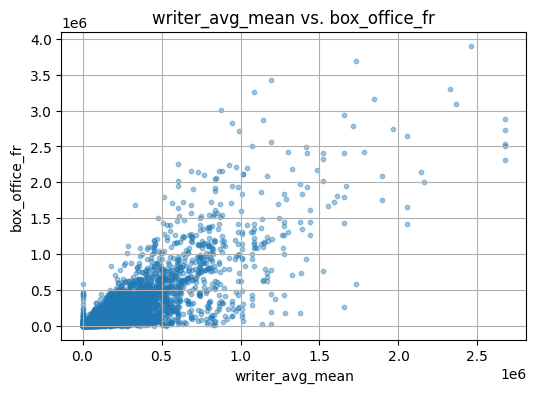

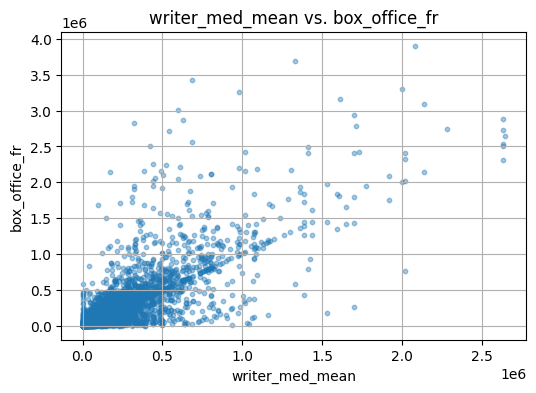

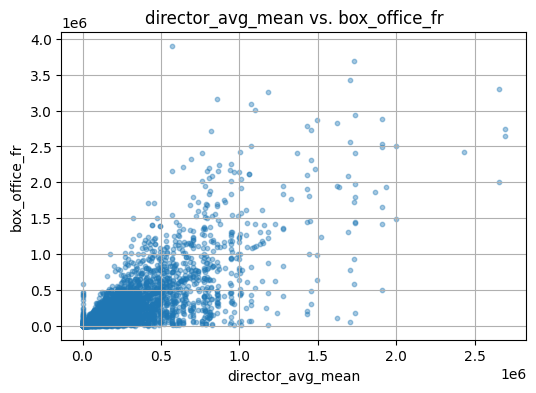

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Charger le DataFrame préparé
df = pd.read_csv('maxcleaned.csv')

# 2. Statistiques descriptives des variables numériques
print("=== Statistiques descriptives ===")
print(df.describe().T)

# 3. Corrélation de chaque feature avec la cible
corr = df.corr()['box_office_fr'].abs().sort_values(ascending=False)
print("\n=== Top 10 des corrélations absolues avec box_office_fr ===")
print(corr.head(10))

# 4. Scatter plots pour les 3 features les plus corrélées (hors cible)
top_feats = corr.index[1:4]  # on ignore 'box_office_fr' lui-même
for feat in top_feats:
    plt.figure(figsize=(6,4))
    plt.scatter(df[feat], df['box_office_fr'], alpha=0.4, s=10)
    plt.title(f'{feat} vs. box_office_fr')
    plt.xlabel(feat)
    plt.ylabel('box_office_fr')
    plt.grid(True)
    plt.show()


In [1]:
import sys
print("Exécutable :", sys.executable)
print("Chemins de recherche :", sys.path)


Exécutable : /home/maxime/DataDevIA/predictioncinema/popularity_movie_prediction_project/ML/.venv/bin/python
Chemins de recherche : ['/usr/lib/python312.zip', '/usr/lib/python3.12', '/usr/lib/python3.12/lib-dynload', '', '/home/maxime/DataDevIA/predictioncinema/popularity_movie_prediction_project/ML/.venv/lib/python3.12/site-packages']


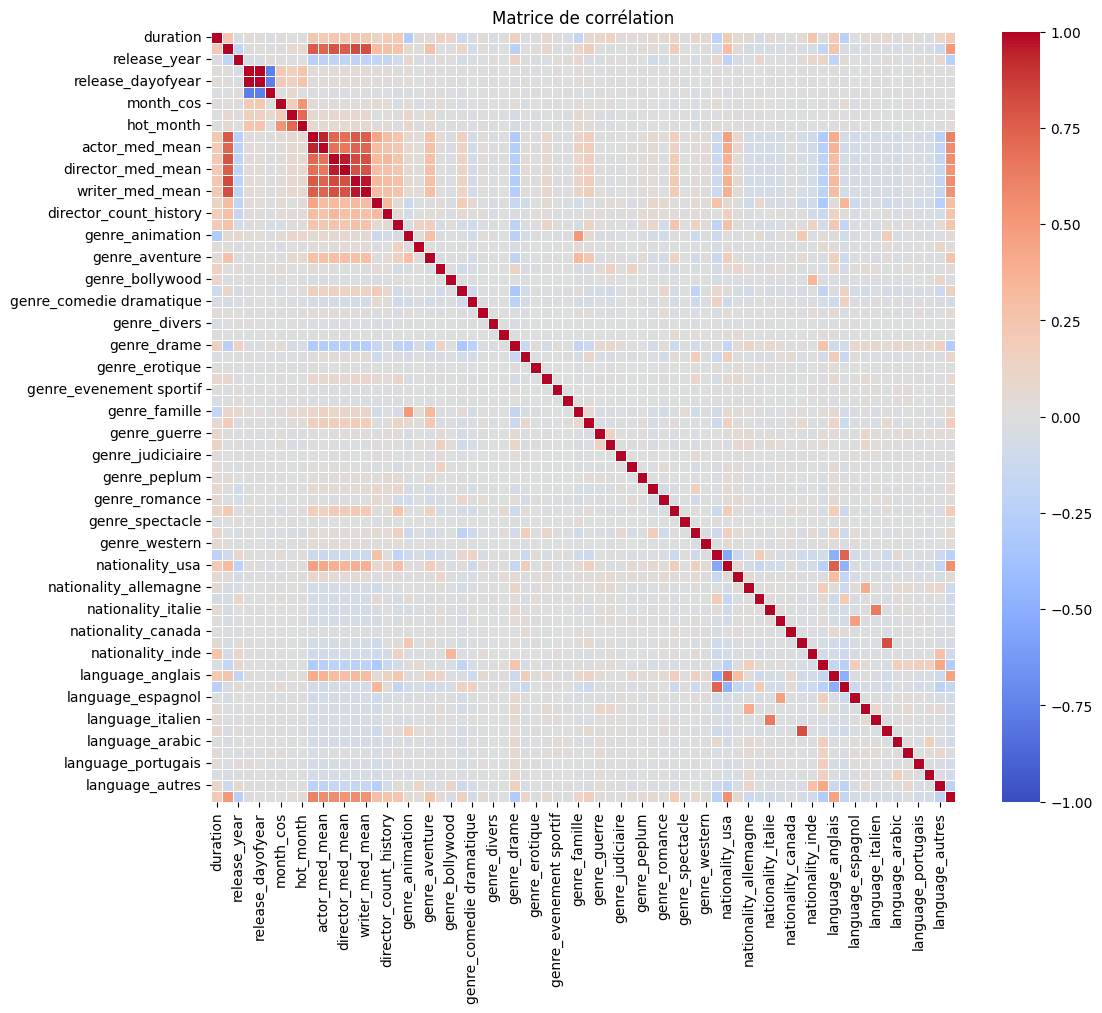

In [3]:
import seaborn as sns

plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), cmap='coolwarm', center=0, 
            vmin=-1, vmax=1, fmt=".2f", linewidths=0.5)
plt.title("Matrice de corrélation")
plt.show()
